# TP2 – Profiling systématique des produits France (Open Food Facts)

## Source des données et licence

Les données utilisées dans ce notebook proviennent d'[Open Food Facts](https://world.openfoodfacts.org).

- La structure de la base de données est distribuée sous licence **Open Database License (ODbL)**.
- Le contenu individuel (données produits) est distribué sous licence **Database Contents License (DbCL) 1.0**.
- Les éventuelles images de produits sont distribuées sous licence **Creative Commons Attribution-ShareAlike (CC BY-SA)**.

Conformément à ces licences, ce travail crédite Open Food Facts comme source des données.
Tout jeu de données dérivé partagé publiquement (par exemple `produits_france.parquet`)
est repartagé sous les mêmes conditions (ODbL / DbCL).

## 0. Préparation

Chargement du sous-ensemble France (déjà construit une fois, voir Annexe A) et définition
des fonctions utilitaires utilisées dans tout le notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

france_dataframe = pd.read_parquet('../data/produits_france.parquet')
print(france_dataframe.shape)
france_dataframe.info()

(1247336, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1247336 entries, 0 to 1247335
Data columns (total 8 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   product_name      1247336 non-null  object 
 1   brands            704417 non-null   str    
 2   code              1247336 non-null  str    
 3   nutriments        937673 non-null   object 
 4   nutriscore_score  463757 non-null   float64
 5   nutriscore_grade  1222296 non-null  str    
 6   countries_tags    1247336 non-null  object 
 7   categories_tags   661380 non-null   object 
dtypes: float64(1), object(4), str(3)
memory usage: 104.4+ MB


### Fonctions utilitaires

In [3]:
def extract_nutrients(nutrients_list, names_to_find):
    """
    Extracts specific nutrients from the nested "nutriments" list of a single
    product (a list of dicts, each with a "name" and a "100g" value).

    names_to_find: dict mapping {nutrient name in the raw data -> target column name}
    Returns a dict {target column name -> value}, with None for missing nutrients.
    """
    result = {column_name: None for column_name in names_to_find.values()}

    if nutrients_list is None:
        return result

    for item in nutrients_list:
        name = item.get('name')
        if name in names_to_find:
            result[names_to_find[name]] = item.get('100g')

    return result


def extract_main_name(names_list):
    """
    Extracts a single readable product name from the nested "product_name"
    list (a list of {lang, text} dicts, one per language).
    """
    if names_list is None or len(names_list) == 0:
        return None
    for item in names_list:
        if item.get("lang") == "main":
            return item.get("text")
    return names_list[0].get("text")  # fallback: no "main" entry, take the first one


def analyze_distribution(dataframe, column, min_value=0, max_value=100, display_name=None):
    """
    Complete analysis of a numeric "per 100g" column: describe, missing rate,
    impossible values (outside [min_value, max_value]), worst cases, histogram.

    Returns a dict of results reusable for the final summary.
    """
    display_name = display_name or column
    print(f"--- {display_name} ---")

    stats = dataframe[column].describe()
    print(stats)

    missing_rate = (1 - stats['count'] / len(dataframe)) * 100
    print(f"Taux de valeurs manquantes pour {display_name} : {missing_rate:.2f} %")

    impossible_values = dataframe[
        (dataframe[column] < min_value) | (dataframe[column] > max_value)
    ]
    impossible_rate = (len(impossible_values) / len(dataframe)) * 100
    print(f"{len(impossible_values)} produits ont une valeur de {display_name} impossible, "
          f"soit {impossible_rate:.4f} %")

    sorted_impossible_values = impossible_values.sort_values(column, ascending=False)
    print(sorted_impossible_values[['product_name_main', column]].head(5))

    if len(sorted_impossible_values) > 0:
        worst_index = sorted_impossible_values.index[0]
        print("Donnée brute des nutriments pour la pire ligne (vérification de contexte) :")
        print(dataframe['nutriments'].loc[worst_index])

    dataframe[column].hist(bins=30)
    plt.title(f"Distribution : {display_name}")
    plt.show()

    return {
        "column": column,
        "missing_rate": missing_rate,
        "nb_impossible_values": len(impossible_values),
        "impossible_rate": impossible_rate,
        "impossible_values": impossible_values,
    }

### Préparation des données : extraction des champs imbriqués

In [4]:
# Extract the three key nutrients (nested inside "nutriments") into flat columns
names_to_find = {
    'energy-kcal': 'energy_kcal_100g',
    'sugars': 'sugars_100g',
    'salt': 'salt_100g',
}

extracted_nutrients = pd.DataFrame(
    france_dataframe['nutriments'].apply(lambda x: extract_nutrients(x, names_to_find)).tolist()
)

france_dataframe = pd.concat(
    [france_dataframe.reset_index(drop=True), extracted_nutrients.reset_index(drop=True)],
    axis=1,
)

# Extract a single readable product name (nested inside "product_name")
france_dataframe["product_name_main"] = france_dataframe["product_name"].apply(extract_main_name)

france_dataframe[['product_name_main', 'energy_kcal_100g', 'sugars_100g', 'salt_100g']].head()

,product_name_main,energy_kcal_100g,sugars_100g,salt_100g
0,Véritable pâte à tartiner noisettes chocolat noir,617.0,32.0,0.01
1,Escalope de dinde,NaN,NaN,NaN
2,Madeleine Framboise,NaN,NaN,NaN
3,Croissants margarine,NaN,NaN,NaN
4,Glaces vegetales des alpes,200.0,26.6,0.10


## 1. Distributions et valeurs impossibles

Pour chaque variable clé, on regarde sa distribution (`describe`, histogramme) et on repère
les valeurs qui sortent d'une plage physiquement/nutritionnellement plausible.

### Nutri-Score

Plage plausible : **-15 à 40** (l'échelle officielle du Nutri-Score pour la plupart des
catégories d'aliments ; certaines catégories comme les fromages ou les boissons utilisent des
barèmes légèrement différents, ce qui peut expliquer des valeurs juste en dehors de cette plage).

--- Nutri-Score ---
count    463757.000000
mean         11.173912
std          10.085373
min         -17.000000
25%           3.000000
50%          11.000000
75%          19.000000
max          53.000000
Name: nutriscore_score, dtype: float64
Taux de valeurs manquantes pour Nutri-Score : 62.82 %
445 produits ont une valeur de Nutri-Score impossible, soit 0.0357 %
              product_name_main  nutriscore_score
598496            Sambal Badjak              53.0
262293              Milk domior              53.0
562186  Bonbons choco halloween              51.0
602740  Assortiment de chocolat              51.0
629841       Figurine de Pâques              51.0
Donnée brute des nutriments pour la pire ligne (vérification de contexte) :
[{'name': 'energy', 'value': None, '100g': 28166.0, 'serving': None, 'unit': 'kJ', 'prepared_value': None, 'prepared_100g': None, 'prepared_serving': None, 'prepared_unit': None}
 {'name': 'nova-group', 'value': None, '100g': 80.0, 'serving': None, 'unit': '

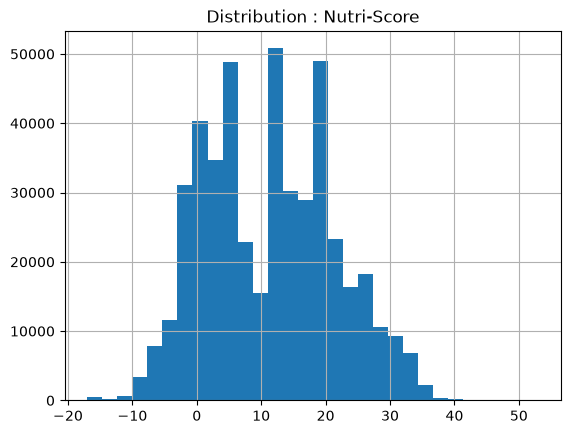

In [5]:
nutriscore_results = analyze_distribution(france_dataframe, 'nutriscore_score', -15, 40, "Nutri-Score")

**Constats :** seulement 37% des produits ont un Nutri-Score renseigné (`missing_rate`). La
médiane (11) est très proche de la moyenne (11.17), ce qui suggère une distribution plutôt
symétrique. Seulement 70 valeurs distinctes sont utilisées sur tout le jeu de données (voir
Cardinalités plus bas) alors que la colonne est stockée en `float64` — le Nutri-Score se comporte
en pratique comme une échelle entière discrète. Un petit nombre de produits sortent de [-15, 40],
à vérifier par catégorie pour savoir s'il s'agit de cas limites légitimes ou d'erreurs de
données.

### Sucre (`sugars_100g`)

Plage plausible : **0 à 100** g/100g — c'est un pourcentage, donc 100 est la limite
mathématique absolue.

--- sucre ---
count    8.807820e+05
mean     1.333721e+27
std      1.251697e+30
min      0.000000e+00
25%      6.000000e-01
50%      3.500000e+00
75%      1.978000e+01
max      1.174717e+33
Name: sugars_100g, dtype: float64
Taux de valeurs manquantes pour sucre : 29.39 %
47 produits ont une valeur de sucre impossible, soit 0.0038 %
                     product_name_main   sugars_100g
908280          Ristretto decaffeinato  1.174717e+33
67649                          Banan's  7.400000e+04
1154322                            NaN  5.555000e+03
598171                      LEMON-LIME  2.400000e+03
19446    Dessert végétal chocolat noir  1.500000e+03
Donnée brute des nutriments pour la pire ligne (vérification de contexte) :
[{'name': 'sugars', 'value': None, '100g': 1.174717435652794e+33, 'serving': None, 'unit': 'g', 'prepared_value': None, 'prepared_100g': None, 'prepared_serving': None, 'prepared_unit': None}]


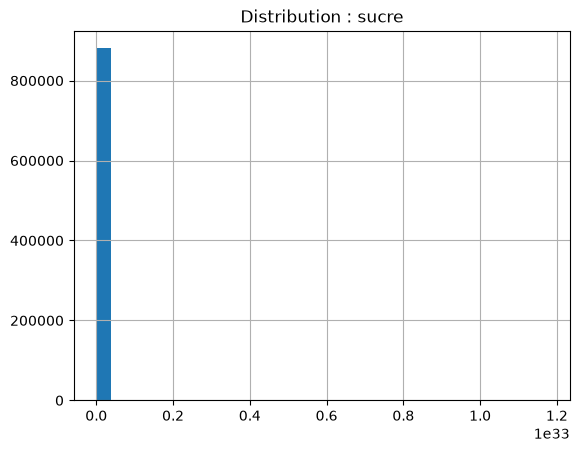

In [6]:
sugar_results = analyze_distribution(france_dataframe, 'sugars_100g', 0, 100, "sucre")

**Constats :** taux de manquants de 29.4%. Seulement 47 valeurs impossibles (0.0038%), mais
extrêmes : de 101 jusqu'à 74 000, avec une valeur aberrante à 1.17×10³³ (comparable à la masse du
Soleil en grammes) — cette seule valeur suffit à rendre la moyenne (1.33×10²⁷) et l'écart-type
totalement inutilisables, alors que la médiane (3.5) et les quartiles restent fiables. Deux
sous-cas à distinguer : des valeurs juste au-dessus de 100 (ex : sirop d'agave à ~101-105,
probablement un arrondi de mesure sur un produit presque 100% sucre) contre des valeurs
clairement absurdes (300, 1500, 74000, 10³³), qui sont de vraies erreurs de saisie.

### Sel (`salt_100g`)

Plage plausible : **0 à 100** g/100g, même raisonnement que pour le sucre.

--- sel ---
count    826467.000000
mean          1.278683
std           9.205121
min           0.000000
25%           0.075000
50%           0.550000
75%           1.300000
max        5000.000000
Name: salt_100g, dtype: float64
Taux de valeurs manquantes pour sel : 33.74 %
54 produits ont une valeur de sel impossible, soit 0.0043 %
                             product_name_main    salt_100g
852610                      Capers, Non Pareil  5000.000000
1067377                         Roasted Sesame  3333.333252
618213                              BCAA Sport  2500.000000
665442   Garden Stix French Onion & Sour Cream  2150.000000
913527                               Drink mix  1387.500000
Donnée brute des nutriments pour la pire ligne (vérification de contexte) :
[{'name': 'sodium', 'value': None, '100g': 2000.0, 'serving': None, 'unit': 'g', 'prepared_value': None, 'prepared_100g': None, 'prepared_serving': None, 'prepared_unit': None}
 {'name': 'fiber', 'value': None, '100g': 0.0, 'servi

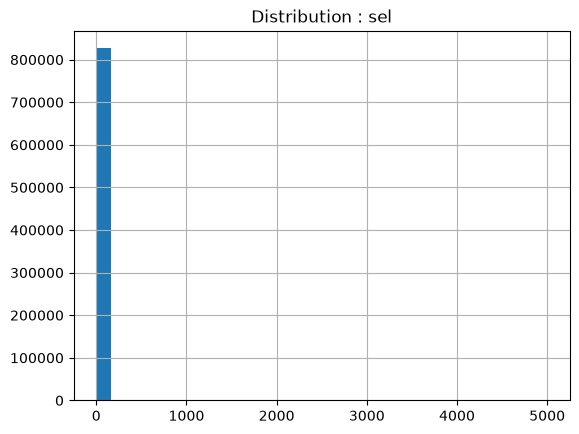

In [7]:
salt_results = analyze_distribution(france_dataframe, 'salt_100g', 0, 100, "sel")

**Constats :** taux de manquants de 33.7%. 54 valeurs impossibles (0.0043%), de 172 jusqu'à
5000. Cas remarquable : "Capers" a `salt_100g = 5000` et `sodium_100g = 2000` — un ratio exact de
2.5, conforme à la formule standard sel ≈ sodium × 2.5. Ça suggère que les deux valeurs sont
cohérentes entre elles mais toutes deux décalées d'un facteur ~1000 (comme si elles avaient été
saisies en milligrammes tout en étant étiquetées en grammes) — une vraie erreur de magnitude à la
saisie plutôt qu'une faute isolée. Voir la Section 4 pour une vérification systématique de ce
schéma sur l'ensemble des données.

### Énergie (`energy_kcal_100g`)

Plage plausible : **0 à 900** kcal/100g. 0 est le plancher physique (l'énergie ne peut pas être
négative). 900 est un plafond théorique dérivé de la science nutritionnelle : les lipides sont le
macronutriment le plus dense en énergie, avec environ 9 kcal/g — un produit composé à ~100% de
matière grasse (une huile pure, par exemple) plafonne donc autour de 100g × 9 kcal/g = 900
kcal/100g, cohérent avec les huiles alimentaires réelles, qui se situent autour de 880-900
kcal/100g.

--- énergie ---
count    8.878590e+05
mean     1.603036e+10
std      1.510481e+13
min     -1.138600e+02
25%      1.140000e+02
50%      2.620000e+02
75%      4.000000e+02
max      1.423270e+16
Name: energy_kcal_100g, dtype: float64
Taux de valeurs manquantes pour énergie : 28.82 %
1117 produits ont une valeur de énergie impossible, soit 0.0896 %
                    product_name_main  energy_kcal_100g
752504                 India Pale Ale      1.423270e+16
1183917                           NaN      3.333333e+06
1234368                           NaN      2.490600e+05
1097937                 3336420100097      1.402060e+05
1125074  Furikaké shiso et sésame bio      4.654210e+04
Donnée brute des nutriments pour la pire ligne (vérification de contexte) :
[{'name': 'vitamin-b9', 'value': None, '100g': 4.350000017439015e-05, 'serving': None, 'unit': 'g', 'prepared_value': None, 'prepared_100g': None, 'prepared_serving': None, 'prepared_unit': None}
 {'name': 'selenium', 'value': None, '100g': 

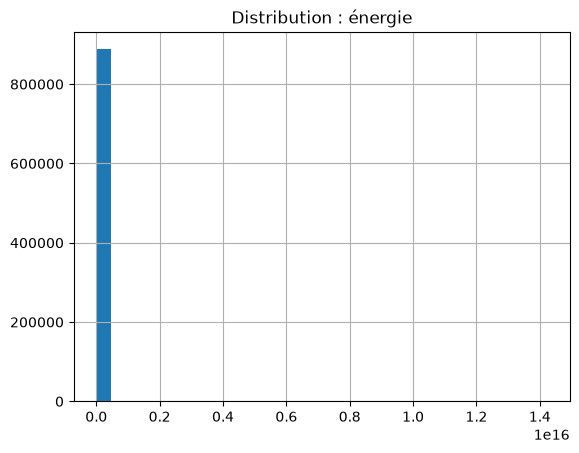

In [8]:
energy_results = analyze_distribution(france_dataframe, 'energy_kcal_100g', 0, 900, "énergie")

**Constats :** taux de manquants de 28.8%. 1117 valeurs impossibles (0.0896%) — environ 20
fois plus fréquent que pour le sucre ou le sel, ce qui fait de l'énergie le nutriment le plus
"sale" des trois. Contient aussi des valeurs négatives (min = -113.86), un type d'anomalie non
rencontré sur les deux autres colonnes. Pire cas : 1.42×10¹⁶ kcal sur une India Pale Ale, alors
que les autres nutriments de la même ligne (zinc, alcool à un taux plausible de 1.27% vol)
paraissent parfaitement normaux — l'erreur est isolée à ce seul champ, pas à toute la ligne.
Plusieurs des pires lignes ont aussi un `product_name` vide ou correspondant à un code-barres, ce
qui suggère que ce sont globalement des fiches produit mal renseignées.

## 2. Cardinalités

Nombre de valeurs distinctes par colonne. Les colonnes de type liste (`nutriments`,
`product_name`, `countries_tags`, `categories_tags`) ne peuvent pas être hashées directement par
`nunique()`, elles sont donc exclues ici.

In [9]:
columns_to_exclude = ['nutriments', 'product_name', 'countries_tags', 'categories_tags']

for column in france_dataframe.columns:
    if column in columns_to_exclude:
        print(f'{column:20s} -> (colonne de listes, cardinalité non calculable directement)')
        continue

    nb_unique = france_dataframe[column].nunique()
    print(f'{column:20s} -> {nb_unique:>10,} valeurs uniques sur {len(france_dataframe):,} lignes')

product_name         -> (colonne de listes, cardinalité non calculable directement)
brands               ->    113,784 valeurs uniques sur 1,247,336 lignes
code                 ->  1,247,309 valeurs uniques sur 1,247,336 lignes
nutriments           -> (colonne de listes, cardinalité non calculable directement)
nutriscore_score     ->         70 valeurs uniques sur 1,247,336 lignes
nutriscore_grade     ->          7 valeurs uniques sur 1,247,336 lignes
countries_tags       -> (colonne de listes, cardinalité non calculable directement)
categories_tags      -> (colonne de listes, cardinalité non calculable directement)
energy_kcal_100g     ->     19,073 valeurs uniques sur 1,247,336 lignes
sugars_100g          ->     11,557 valeurs uniques sur 1,247,336 lignes
salt_100g            ->     14,344 valeurs uniques sur 1,247,336 lignes
product_name_main    ->    734,820 valeurs uniques sur 1,247,336 lignes


**Constats :** `code` a 1 247 309 valeurs uniques sur 1 247 336 lignes — environ 27 lignes
sont dupliquées, étudiées en Section 3. `nutriscore_score` n'a que 70 valeurs distinctes, ce qui
confirme qu'il se comporte comme une échelle entière discrète plutôt qu'un flottant continu.
`product_name_main` a 734 820 valeurs uniques sur 1 247 336 lignes, ce qui veut dire que beaucoup
de produits partagent des noms génériques.

## 3. Doublons de codes-barres

In [10]:
nb_duplicates = france_dataframe['code'].duplicated().sum()
print(f'Codes-barres en doublon : {nb_duplicates}')

duplicate_codes = france_dataframe[france_dataframe['code'].duplicated(keep=False)].sort_values('code')
print(duplicate_codes[['code', 'product_name_main', 'brands']])

Codes-barres en doublon : 27
                   code                                  product_name_main  \
4238      0059527070430                                    Goji Snack Bars   
1058458   0059527070430                                               Goji   
4243      0059527171687            Tast Of Nature Pomegranate Granenreep @   
1058459   0059527171687                                        Pomegranate   
4256      0059527401555                     Almond Fruit And Nut Snack Bar   
1058453   0059527401555                                             Almond   
4257      0059527501552                  Cranberry Fruit and Nut Snack Bar   
1058449   0059527501552                                          Cranberry   
4259      0059527601559  Coconut, Cranberry, Brazil Nut Snack Bar Varie...   
1058456   0059527601559                                         Brazil nut   
1056819   2000000151610                                                NaN   
1056829   2000000151610            

**Constats :** 27 codes-barres dupliqués (54 lignes) sur plus d'1,2M de produits — un volume
très faible dans l'ensemble, mais avec plusieurs schémas distincts à documenter : de vrais
doublons exacts (même nom et même marque, ex : "Jardin anglais", "Sauce barbecue"), des variantes
de casse/nommage du même produit (les cinq barres "Taste of Nature"), une faute de frappe
("Saupon" vs "Saumon fumé sauvage du pacifique"), et un cas particulièrement préoccupant où le
même code-barres (`2000000151619`) correspond à deux produits manifestement différents ("MNMS"
vs "medaillon végétal") — plus qu'un doublon, c'est une remise en cause de l'hypothèse selon
laquelle `code` identifie un produit de façon unique et fiable.

## 4. Incohérences d'unités

Deux vérifications complémentaires : (a) est-ce que la métadonnée `unit` déclarée est cohérente
pour un nutriment donné à travers le jeu de données, et (b) est-ce que des champs physiquement
liés respectent leur ratio de conversion connu (énergie en kJ vs kcal, sel vs sodium).

### (a) Unités déclarées par nutriment

In [11]:
units_used = {}

for nutrients_list in france_dataframe['nutriments'].dropna():
    for item in nutrients_list:
        name = item['name']
        unit = item.get('unit')
        units_used.setdefault(name, set()).add(unit)

for name in ['salt', 'sodium', 'sugars', 'energy-kcal', 'energy-kj', 'energy']:
    print(name, '->', units_used.get(name))

salt -> {None, '', 'g', 'mg'}
sodium -> {None, 'g', 'mg'}
sugars -> {None, '', 'g'}
energy-kcal -> {None, 'kcal'}
energy-kj -> {None, 'kj', 'kJ'}
energy -> {None, 'kcal', 'kj', 'kJ'}


In [12]:
# Does the declared unit actually affect the stored "100g" number, or is it already
# normalized? Compare the raw salt value depending on its declared unit.
def get_100g_and_unit(nutrients_list, nutrient_name):
    if nutrients_list is None:
        return None, None
    for item in nutrients_list:
        if item['name'] == nutrient_name:
            return item.get('100g'), item.get('unit')
    return None, None

raw_salt = france_dataframe['nutriments'].apply(lambda x: get_100g_and_unit(x, 'salt'))
france_dataframe['salt_100g_raw'] = raw_salt.apply(lambda t: t[0])
france_dataframe['salt_unit'] = raw_salt.apply(lambda t: t[1])

print(france_dataframe.groupby('salt_unit')['salt_100g_raw'].describe())

              count      mean       std   min      25%    50%      75%     max
salt_unit                                                                     
                7.0  0.571429  0.419461  0.01  0.28500  0.420  1.00000     1.0
g          826454.0  1.278694  9.205193  0.00  0.07500  0.550  1.30000  5000.0
mg              6.0  0.595333  0.408069  0.02  0.45125  0.501  0.81175     1.2


**Constats :** la métadonnée `unit` déclarée est incohérente pour `salt` et `sodium`
(majoritairement `'g'`, mais aussi `'mg'`, `''`, ou absente sur une poignée de lignes). Mais en
regroupant la valeur brute `100g` par unité déclarée, le groupe `'mg'` est sur la **même échelle**
que le groupe `'g'` (moyennes autour de 0.5-1.3 dans les deux cas), pas ~1000 fois plus élevé
comme ce serait le cas si le nombre lui-même était stocké en milligrammes. Ça veut dire qu'Open
Food Facts normalise déjà la valeur stockée en grammes, quelle que soit l'unité déclarée —
l'incohérence de métadonnée est réelle mais globalement inoffensive ici (et ne concerne que ~13
lignes sur 826 467 non manquantes). Ça confirme aussi que l'anomalie "Capers" (sel = 5000, unité
déclarée `'g'`) est une vraie erreur de magnitude à la saisie, pas un artefact de conversion
d'unité.

### (b) Ratios de cohérence entre champs

In [13]:
# Extract sodium and energy in kJ, needed for the two ratio checks below
extra_names_to_find = {
    "sodium": "sodium_100g",
    "energy-kj": "energy_kj_100g",
}

extra_nutrients = pd.DataFrame(
    france_dataframe["nutriments"].apply(lambda x: extract_nutrients(x, extra_names_to_find)).tolist()
)

france_dataframe = pd.concat(
    [france_dataframe.reset_index(drop=True), extra_nutrients.reset_index(drop=True)],
    axis=1,
)

In [14]:
# Energy ratio: kJ / kcal, theoretical value ~4.184
energy_ratio = france_dataframe['energy_kj_100g'] / france_dataframe['energy_kcal_100g']
print("--- Ratio kJ / kcal ---")
print(energy_ratio.describe())

suspect_energy = france_dataframe[(energy_ratio < 3.5) | (energy_ratio > 4.8)]
suspect_energy_finite = suspect_energy[np.isfinite(energy_ratio.loc[suspect_energy.index])]
print(f"{len(suspect_energy):,} lignes suspectes au total, "
      f"{len(suspect_energy_finite):,} avec un ratio fini réellement suspect "
      f"(le reste vient de energy_kcal_100g = 0, un artefact de division par zéro)")

# Salt ratio: salt / sodium, theoretical value ~2.5
salt_ratio = france_dataframe['salt_100g'] / france_dataframe['sodium_100g']
print("\n--- Ratio sel / sodium ---")
print(salt_ratio.describe())

suspect_salt = france_dataframe[(salt_ratio < 2.0) | (salt_ratio > 3.0)]
suspect_salt_finite = suspect_salt[np.isfinite(salt_ratio.loc[suspect_salt.index])]
print(f"{len(suspect_salt):,} lignes suspectes au total, "
      f"{len(suspect_salt_finite):,} avec un ratio fini réellement suspect "
      f"(le reste vient de sodium_100g = 0, un artefact de division par zéro)")

--- Ratio kJ / kcal ---
count    8.688810e+05
mean              NaN
std               NaN
min              -inf
25%      4.121212e+00
50%      4.174528e+00
75%      4.226190e+00
max               inf
dtype: float64
69,051 lignes suspectes au total, 65,779 avec un ratio fini réellement suspect (le reste vient de energy_kcal_100g = 0, un artefact de division par zéro)

--- Ratio sel / sodium ---
count    717979.0
mean          inf
std           NaN
min           0.0
25%           2.5
50%           2.5
75%           2.5
max           inf
dtype: float64
3,460 lignes suspectes au total, 3,192 avec un ratio fini réellement suspect (le reste vient de sodium_100g = 0, un artefact de division par zéro)


c:\Users\Administrateur\Documents\Programmation\tp_fil_rouge\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\Administrateur\Documents\Programmation\tp_fil_rouge\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


**Constats :** les deux ratios tombent quasiment pile sur leur valeur théorique pour la
majorité des données — médiane kJ/kcal ≈ 4.17 (attendu 4.184), et médiane/Q1/Q3 sel/sodium tous
exactement à 2.5. C'est le signal d'"incohérence d'unités" le plus fiable de ce jeu de données :
contrairement à la métadonnée `unit` déclarée (globalement du bruit sans conséquence), ces ratios
détectent directement les erreurs de magnitude, quelle que soit l'unité déclarée. Le ratio
sel/sodium étant *exactement* 2.5 pour la plupart des lignes suggère aussi qu'un champ est souvent
calculé à partir de l'autre plutôt que mesuré indépendamment — une observation à noter sur la
distinction "donnée dérivée vs donnée mesurée".

## 5. Synthèse — qu'est-ce qui semble le plus "sale" dans ces données

- **Les valeurs manquantes** sont le problème le plus fréquent en volume : 28 à 38% de
  manquants sur chaque champ nutritionnel clé (Nutri-Score, sucre, sel, énergie), et seulement
  ~75% des produits ont ne serait-ce qu'une donnée de nutriments renseignée.
- **Les valeurs impossibles** sont rares en nombre (0.004 à 0.09% selon le champ) mais extrêmes
  en magnitude — une seule ligne peut atteindre 10³³ ou 10¹⁶, suffisant pour rendre la moyenne et
  l'écart-type totalement inutilisables ; la médiane et les quartiles restent les statistiques
  fiables tout au long de l'analyse.
- **L'énergie** est le plus sale des trois nutriments clés (environ 20 fois plus de valeurs
  impossibles que le sucre ou le sel), et le seul avec un type d'anomalie distinct (les valeurs
  négatives).
- **Les doublons de codes-barres** sont négligeables en volume (27 sur plus d'1,2M) mais
  incluent un cas réellement préoccupant où le même code-barres correspond à deux produits
  différents, ce qui remet en cause la fiabilité de `code` comme identifiant unique.
- **Les incohérences d'unités** : la métadonnée `unit` déclarée est bruitée mais globalement
  inoffensive (les valeurs sont déjà normalisées en grammes) ; le vrai signal se trouve dans les
  ratios croisés (kJ/kcal, sel/sodium), excellents sur la majorité des données et capables de
  repérer de vraies erreurs de magnitude (comme le cas "Capers") que de simples vérifications de
  plage n'auraient pas expliquées.
- **La saleté structurelle** : plusieurs champs qui ressemblent à de simples valeurs sont en
  réalité des structures imbriquées (`nutriments` comme liste de dictionnaires par nutriment,
  `product_name` comme liste de dictionnaires par langue), qu'il faut aplatir avant toute analyse
  — un problème de qualité/d'exploitabilité des données à documenter à part entière, indépendant
  des valeurs elles-mêmes.

## Partie 2 — Vers la décision de périmètre

Les sections précédentes répondent à la consigne de profiling du TP2 (distributions,
cardinalités, doublons, incohérences d'unités, valeurs impossibles). Cette deuxième partie
prépare un autre livrable : la décision d'équipe sur le périmètre de lancement (rayons
couverts, seuil de complétude), destinée à alimenter `docs/perimetre.md`. Elle réutilise les
mêmes données que le profiling ci-dessus, mais ne fait pas partie de la consigne TP2
proprement dite.

## 6. Rayons candidats

Le projet vise 5 à 8 rayons couverts au lancement. `categories_tags` porte cette information,
sous forme de tags hiérarchiques (du plus général au plus spécifique) — plusieurs tags par
produit, donc `explode()` est nécessaire avant de compter les fréquences.

In [15]:
category_counts = france_dataframe['categories_tags'].explode().value_counts()
print(category_counts.head(30))

categories_tags
en:plant-based-foods-and-beverages         190606
en:plant-based-foods                       165363
en:snacks                                  108197
en:sweet-snacks                             90947
en:meats-and-their-products                 83549
en:beverages                                70703
en:meats                                    63989
en:dairies                                  59861
en:fruits-and-vegetables-based-foods        51085
en:cereals-and-potatoes                     50203
en:fermented-foods                          48850
en:fermented-milk-products                  47365
en:meals                                    45666
en:spreads                                  42476
en:biscuits-and-cakes                       39849
en:desserts                                 38759
en:prepared-meats                           37946
en:condiments                               37444
en:cheeses                                  33826
en:breakfasts                     

Les tags les plus fréquents mélangent des niveaux de granularité très différents — des tags
très généraux comme `en:plant-based-foods-and-beverages` (190 606 produits, quasiment "tout ce
qui n'est pas d'origine animale") à côté de tags bien plus précis comme `en:sodas` ou
`en:cheeses`. Pour des rayons de supermarché, il faut choisir un niveau de découpage
intermédiaire, pas prendre les tags les plus fréquents tels quels.

In [16]:
rayon_groups = {
    "dairy": ["en:dairies", "en:fermented-milk-products", "en:cheeses"],
    "beverages": ["en:beverages", "en:plant-based-beverages"],
    "sweet_snacks": ["en:sweet-snacks", "en:biscuits-and-cakes", "en:desserts",
                      "en:confectioneries", "en:sweet-spreads"],
    "meats_and_fish": ["en:meats-and-their-products", "en:meats", "en:prepared-meats",
                        "en:seafood", "en:poultries"],
    "savory_grocery": ["en:condiments", "en:sauces", "en:cereals-and-potatoes",
                        "en:cereals-and-their-products"],
    "prepared_frozen": ["en:meals", "en:frozen-foods"],
    "fruits_and_vegetables": ["en:fruits-and-vegetables-based-foods", "en:fruits-based-foods"],
    "breakfast": ["en:breakfasts"],
}

# Reverse lookup: tag -> rayon name, built once for speed
tag_to_rayon = {}
for rayon_name, tags in rayon_groups.items():
    for tag in tags:
        tag_to_rayon[tag] = rayon_name


def matching_rayons(product_tags):
    if product_tags is None:
        return set()
    return {tag_to_rayon[tag] for tag in product_tags if tag in tag_to_rayon}


france_dataframe["matched_rayons"] = france_dataframe["categories_tags"].apply(matching_rayons)
france_dataframe["nb_matched_rayons"] = france_dataframe["matched_rayons"].apply(len)

print("Nombre de rayons candidats touchés par produit :")
print(france_dataframe["nb_matched_rayons"].value_counts().sort_index())

coverage = (france_dataframe["nb_matched_rayons"] > 0).mean() * 100
print(f"\nCouverture par au moins un des {len(rayon_groups)} rayons candidats : {coverage:.1f}%")

multi_rayon = (france_dataframe["nb_matched_rayons"] > 1).mean() * 100
print(f"Produits qui tombent dans plusieurs rayons à la fois : {multi_rayon:.1f}%")

Nombre de rayons candidats touchés par produit :
nb_matched_rayons
0    730158
1    416086
2     92808
3      8138
4       142
5         4
Name: count, dtype: int64

Couverture par au moins un des 8 rayons candidats : 41.5%
Produits qui tombent dans plusieurs rayons à la fois : 8.1%


**Constats :** avec ces 8 rayons candidats, la couverture est de 41,5% et 8,1% des produits
touchent plusieurs rayons à la fois — un chevauchement à anticiper dans la règle d'assignation
d'un produit à un rayon.

In [17]:
missing_categories = france_dataframe["categories_tags"].apply(lambda tags: tags is None or len(tags) == 0)
print(f"Produits sans categories_tags renseigné : {missing_categories.mean() * 100:.1f}%")

Produits sans categories_tags renseigné : 50.5%


**Constats :** 50,5% des produits n'ont aucune catégorie renseignée. Sur les 58,5% de
produits non couverts par les 8 rayons candidats, l'essentiel (50,5 points) vient donc de
`categories_tags` manquant, et non d'un découpage trop étroit (~8 points seulement de produits
catégorisés mais hors des 8 rayons). Le vrai facteur limitant pour la couverture du catalogue au
lancement, c'est la complétude de `categories_tags`, pas le nombre de rayons choisis.

Le volume seul ne suffit pas à choisir entre les 8 candidats : il faut aussi regarder la
qualité des données de chaque rayon, en particulier le taux de remplissage du `nutriscore_score`
(la cible du modèle).

In [18]:
for rayon_name, tags in rayon_groups.items():
    is_in_rayon = france_dataframe["categories_tags"].apply(
        lambda product_tags: product_tags is not None and any(tag in tags for tag in product_tags)
    )
    nb_products = is_in_rayon.sum()
    nutriscore_fill_rate = france_dataframe.loc[is_in_rayon, "nutriscore_score"].notna().mean() * 100
    print(f"{rayon_name:25s} -> {nb_products:>8,} produits, "
          f"{nutriscore_fill_rate:.1f}% avec un Nutri-Score renseigné")

dairy                     ->   59,861 produits, 83.9% avec un Nutri-Score renseigné
beverages                 ->   70,703 produits, 52.1% avec un Nutri-Score renseigné
sweet_snacks              ->  150,060 produits, 81.7% avec un Nutri-Score renseigné
meats_and_fish            ->  107,156 produits, 81.6% avec un Nutri-Score renseigné
savory_grocery            ->   87,587 produits, 75.6% avec un Nutri-Score renseigné
prepared_frozen           ->   66,953 produits, 89.8% avec un Nutri-Score renseigné
fruits_and_vegetables     ->   51,085 produits, 76.3% avec un Nutri-Score renseigné
breakfast                 ->   33,299 produits, 66.2% avec un Nutri-Score renseigné


**Constats :** `beverages` a de loin le pire taux de Nutri-Score (52,1%, le plus faible des
8) — son exclusion est cohérente avec la qualité des données, pas seulement une intuition.
`fruits_and_vegetables` a un taux correct (76,3%) mais s'exclut pour une autre raison : les
produits frais vendus en vrac n'ont souvent pas de code-barres, peu compatibles avec une app de
scan. `sweet_snacks`, en revanche, a le deuxième meilleur taux de tous (81,7%) et de loin le plus
gros volume (150 060 produits) — largement mieux renseigné et plus volumineux que `breakfast`
(66,2%, 33 299 produits, le plus petit et le moins bien renseigné des 8). Rien dans les données
ne justifiait d'écarter `sweet_snacks` au profit de `breakfast`.

### Rayons retenus par l'équipe

Décision d'équipe, révisée après ce diagnostic : 5 rayons pour le lancement — Produits laitiers,
Viandes et poissons, Sucré/snacking, Plats préparés et surgelés, Épicerie salée.

- **Boissons** écarté : le taux de Nutri-Score le plus faible des 8 candidats (52,1%)
- **Fruits et légumes** écarté : produits frais souvent vendus sans code-barres, peu adaptés à
  une app de scan, malgré une qualité de données correcte
- **Petit-déjeuner** écarté au profit de **Sucré/snacking** : à qualité de données comparable
  (81,7% vs 66,2%), Sucré/snacking représente plus de 4 fois le volume de Petit-déjeuner

In [19]:
selected_rayons = ["dairy", "meats_and_fish", "sweet_snacks", "prepared_frozen", "savory_grocery"]
selected_rayon_groups = {name: tags for name, tags in rayon_groups.items() if name in selected_rayons}

tag_to_rayon = {}
for rayon_name, tags in selected_rayon_groups.items():
    for tag in tags:
        tag_to_rayon[tag] = rayon_name


def matching_rayons(product_tags):
    if product_tags is None:
        return set()
    return {tag_to_rayon[tag] for tag in product_tags if tag in tag_to_rayon}


france_dataframe["matched_rayons"] = france_dataframe["categories_tags"].apply(matching_rayons)
france_dataframe["nb_matched_rayons"] = france_dataframe["matched_rayons"].apply(len)

coverage = (france_dataframe["nb_matched_rayons"] > 0).mean() * 100
print(f"Couverture par les 5 rayons retenus : {coverage:.1f}%")

multi_rayon = (france_dataframe["nb_matched_rayons"] > 1).mean() * 100
print(f"Produits dans plusieurs rayons retenus à la fois : {multi_rayon:.1f}%")

print(france_dataframe["nb_matched_rayons"].value_counts().sort_index())

Couverture par les 5 rayons retenus : 33.9%
Produits dans plusieurs rayons retenus à la fois : 3.8%
nb_matched_rayons
0    823992
1    375835
2     46750
3       754
4         5
Name: count, dtype: int64


**Constats :** la couverture est de 33,9% avec ces 5 rayons (contre 41,5% avec les 8
candidats), soit environ 423 000 produits en valeur absolue. Le chevauchement remonte légèrement
à 3,8% (contre 2,0% avec Petit-déjeuner) — `sweet_snacks` recoupe un peu plus les autres rayons,
notamment les desserts/pâtisseries qui touchent aussi `dairy` ou `savory_grocery`, mais ça reste
un niveau largement gérable.

## 7. Seuil de complétude

`nutriscore_score` est la cible du modèle (obligatoire). Pour les features, la formule
officielle du Nutri-Score utilise 7 nutriments ; on ne les a pas tous extraits jusqu'ici
(seulement `energy_kcal_100g`, `sugars_100g`, `salt_100g`/`sodium_100g`, utiles au profiling).
Il manque `saturated_fat_100g`, `fiber_100g`, `proteins_100g` et
`fruits_vegetables_nuts_100g`.

In [20]:
remaining_nutrient_names = {
    "saturated-fat": "saturated_fat_100g",
    "fiber": "fiber_100g",
    "proteins": "proteins_100g",
    "fruits-vegetables-nuts": "fruits_vegetables_nuts_100g",
}

remaining_nutrients = pd.DataFrame(
    france_dataframe["nutriments"].apply(lambda x: extract_nutrients(x, remaining_nutrient_names)).tolist()
)

france_dataframe = pd.concat(
    [france_dataframe.reset_index(drop=True), remaining_nutrients.reset_index(drop=True)],
    axis=1,
)

Seuil proposé (à valider en équipe) : `nutriscore_score` renseigné, et au moins 4 des 7
nutriments clés. `salt_100g` est utilisé plutôt que `sodium_100g` dans le décompte : les deux
mesurent la même chose (l'un se déduit de l'autre, voir Section 4b), les compter ensemble
gonflerait artificiellement le score de complétude.

In [21]:
key_nutrients = [
    "energy_kcal_100g", "sugars_100g", "saturated_fat_100g", "salt_100g",
    "fiber_100g", "proteins_100g", "fruits_vegetables_nuts_100g",
]

nb_key_nutrients_present = france_dataframe[key_nutrients].notna().sum(axis=1)

in_a_rayon = france_dataframe["nb_matched_rayons"] > 0
has_nutriscore = france_dataframe["nutriscore_score"].notna()
enough_nutrients = nb_key_nutrients_present >= 4

total = len(france_dataframe)
step1 = in_a_rayon.sum()
step2 = (in_a_rayon & has_nutriscore).sum()
step3 = (in_a_rayon & has_nutriscore & enough_nutrients).sum()

print(f"Catalogue France total                              : {total:,}")
print(f"Dans un des 5 rayons retenus                        : {step1:,} ({step1 / total * 100:.1f}%)")
print(f"...et avec nutriscore_score renseigné               : {step2:,} ({step2 / total * 100:.1f}%)")
print(f"...et avec au moins 4/7 nutriments clés renseignés  : {step3:,} ({step3 / total * 100:.1f}%)")

Catalogue France total                              : 1,247,336
Dans un des 5 rayons retenus                        : 423,344 (33.9%)
...et avec nutriscore_score renseigné               : 343,651 (27.6%)
...et avec au moins 4/7 nutriments clés renseignés  : 342,277 (27.4%)


**Constats :** même schéma qu'avec la première sélection de rayons. Rayon →
`nutriscore_score` renseigné fait perdre 79 693 produits (18,8% du sous-ensemble "dans un
rayon") : c'est la réduction principale. `nutriscore_score` renseigné → au moins 4/7 nutriments
ne fait perdre que 1 374 produits (0,4%) : le seuil de complétude sur les nutriments reste
presque non contraignant une fois `nutriscore_score` exigé — le vrai goulot d'étranglement est
la présence du Nutri-Score lui-même. Taille finale attendue du dataset d'entraînement pour la
brique score : **342 277 produits (27,4% du catalogue France)**, à reporter dans
`docs/perimetre.md` — soit environ 81 000 produits de plus que la première sélection de rayons
(261 367), grâce au remplacement de Petit-déjeuner par Sucré/snacking.

## Annexe A — Construction du sous-ensemble France (à exécuter une fois)

Cette cellule parcourt le fichier source complet (~7 Go) par lots et ne garde que les produits
vendus en France. Elle n'est **pas censée être relancée à chaque exécution** de ce notebook — le
résultat est mis en cache dans `produits_france.parquet`, que la Section 0 charge directement.
Ne relance cette cellule que si le fichier source change ou si le cache doit être reconstruit.

In [1]:
"""
Loads all products sold in France directly into memory, in a pandas
DataFrame — without ever loading the full 7 GB file at once.

We read the file in batches, keep only the rows concerning France, and
assemble everything into a single DataFrame at the end.
"""

import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

SOURCE_FILE = "../data/food.parquet"
BATCH_SIZE = 200_000

# Check the format of countries_tags (list or string)
parquet_file = pq.ParquetFile(SOURCE_FILE)
column_type = parquet_file.schema_arrow.field("countries_tags").type
is_list = pa.types.is_list(column_type) or pa.types.is_large_list(column_type)
print("Colonne countries_tags considérée comme une liste :", is_list)

def contains_france(value):
    if value is None:
        return False
    if is_list:
        return "en:france" in value
    else:
        return "en:france" in [tag.strip() for tag in value.split(",")]

chunks = []
useful_columns = [
    'product_name',
    'brands',
    'code',
    'nutriments',
    'nutriscore_score',
    'nutriscore_grade',
    'countries_tags',
    'categories_tags',
]
rows_read = 0

for batch in parquet_file.iter_batches(batch_size=BATCH_SIZE, columns=useful_columns):
    batch_dataframe = batch.to_pandas()
    rows_read += len(batch_dataframe)

    mask = batch_dataframe["countries_tags"].apply(contains_france)
    filtered_dataframe = batch_dataframe[mask]
    if len(filtered_dataframe) > 0:
        chunks.append(filtered_dataframe)

    rows_found = sum(len(chunk) for chunk in chunks)
    print(f"  {rows_read:,} lignes lues, {rows_found:,} lignes France trouvées", end="\r")

# Final assembly into a single DataFrame, ready to be analyzed
built_france_dataframe = pd.concat(chunks, ignore_index=True)

print(f"\n\nTerminé : {len(built_france_dataframe):,} produits France chargés en mémoire")
print("Mémoire utilisée :", round(built_france_dataframe.memory_usage(deep=True).sum() / 1e6, 1), "Mo")
print(built_france_dataframe.shape)

# Save the France products to avoid rescanning everything
built_france_dataframe.to_parquet('../data/produits_france.parquet')

Colonne countries_tags considérée comme une liste : True
  4,636,471 lignes lues, 1,247,336 lignes France trouvées

Terminé : 1,247,336 produits France chargés en mémoire
Mémoire utilisée : 582.5 Mo
(1247336, 8)


## Annexe B — Vérification de contrôle de l'extraction (développement uniquement)

Contrôle ponctuel confirmant que `extract_nutrients` lit correctement `sugars_100g` depuis le
champ brut `nutriments`, en recalculant la valeur de façon indépendante pour 30 lignes
aléatoires et en comparant. Conservé ici pour la transparence, ne fait pas partie des résultats
de profiling eux-mêmes.

In [ ]:
import random

test_indices = random.sample(range(len(france_dataframe)), 30)

for i in test_indices:
    raw = france_dataframe['nutriments'].iloc[i]
    expected_value = None

    if raw is not None:
        for item in raw:
            if item.get('name') == 'sugars':
                expected_value = item.get('100g')

    obtained_value = france_dataframe['sugars_100g'].iloc[i]

    if expected_value != obtained_value and not (pd.isna(expected_value) and pd.isna(obtained_value)):
        print(f'MISMATCH à la ligne {i} : attendu {expected_value}, obtenu {obtained_value}')

print('Vérification terminée')

In [ ]:
ça me paraît bien beau tout ça